# Bluestock Mutual Fund Capstone
## Day 3 - Exploratory Data Analysis (EDA)
Makarand Patil
Date:04 June 2026

In [9]:
import pandas as pd

nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")
aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")
category = pd.read_csv("../data/raw/05_category_inflows.csv")
folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")
performance = pd.read_csv("../data/processed/07_scheme_performance_clean.csv")
transactions = pd.read_csv("../data/processed/08_investor_transactions_clean.csv")
holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

print("NAV:", nav.shape)
print("AUM:", aum.shape)
print("SIP:", sip.shape)
print("Transactions:", transactions.shape)

NAV: (46000, 3)
AUM: (48, 6)
SIP: (48, 6)
Transactions: (999, 13)


In [10]:
nav.columns


Index(['amfi_code', 'date', 'nav'], dtype='str')

In [11]:
nav['date'] = pd.to_datetime(nav['date'])

nav = nav.sort_values(['amfi_code', 'date'])

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [12]:
import plotly.express as px

fig = px.line(
    nav,
    x='date',
    y='nav',
    color='amfi_code',
    title='Daily NAV Trend of All Schemes (2022-2026)'
)

fig.show()


In [14]:
import plotly.graph_objects as go

fig = px.line(
    nav,
    x='date',
    y='nav',
    color='amfi_code',
    title='NAV Trends with Market Phases'
)

# 2023 Bull Run
fig.add_vrect(
    x0='2023-01-01',
    x1='2023-12-31',
    annotation_text='2023 Bull Run',
    annotation_position='top left'
)

# 2024 Correction
fig.add_vrect(
    x0='2024-01-01',
    x1='2024-12-31',
    annotation_text='2024 Market Correction',
    annotation_position='top right'
)

fig.show()

In [15]:
fig.write_html("nav_trend_analysis.html")

### Insight 1

NAV values across schemes exhibited a strong upward trend during 2023, reflecting a broad market rally. Growth moderated during 2024, indicating a period of market correction and consolidation.

In [16]:
fund_master = pd.read_csv("../data/raw/01_fund_master.csv")

print(fund_master.columns.tolist())

['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25']


In [17]:
nav_named = nav.merge(
    fund_master[['amfi_code', 'scheme_name']],
    on='amfi_code',
    how='left'
)

nav_named.head()

,amfi_code,date,nav,scheme_name
0,100016,2022-01-03,520.4608,HDFC Top 100 Fund - Regular Plan - Growth
1,100016,2022-01-04,515.0971,HDFC Top 100 Fund - Regular Plan - Growth
2,100016,2022-01-05,521.7239,HDFC Top 100 Fund - Regular Plan - Growth
3,100016,2022-01-06,515.7880,HDFC Top 100 Fund - Regular Plan - Growth
4,100016,2022-01-07,515.1639,HDFC Top 100 Fund - Regular Plan - Growth


In [18]:
fig = px.line(
    nav_named,
    x='date',
    y='nav',
    color='scheme_name',
    title='Daily NAV Trend by Scheme (2022-2026)'
)

fig.add_vrect(
    x0='2023-01-01',
    x1='2023-12-31',
    annotation_text='Bull Run',
    annotation_position='top left'
)

fig.add_vrect(
    x0='2024-01-01',
    x1='2024-12-31',
    annotation_text='Market Correction',
    annotation_position='top right'
)

fig.show()

In [19]:
print(aum.columns.tolist())

['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']


In [20]:
sip['month'] = pd.to_datetime(sip['month'])

fig = px.line(
    sip,
    x='month',
    y='sip_inflow_crore',
    markers=True,
    title='Monthly SIP Inflow Trend (2022-2025)'
)

fig.show()

In [21]:
max_row = sip.loc[sip['sip_inflow_crore'].idxmax()]

fig = px.line(
    sip,
    x='month',
    y='sip_inflow_crore',
    markers=True,
    title='Monthly SIP Inflow Trend'
)

fig.add_annotation(
    x=max_row['month'],
    y=max_row['sip_inflow_crore'],
    text=f"ATH ₹{max_row['sip_inflow_crore']:,.0f} Cr",
    showarrow=True
)

fig.show()

In [22]:
fig.write_html("../charts/sip_trend.html")

### Insight 2

SIP inflows showed a strong upward trajectory throughout the analysis period, indicating increasing retail investor participation and growing confidence in mutual fund investing.

In [5]:
import pandas as pd

In [6]:

aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")

print(aum.shape)
print(aum.columns.tolist())

(90, 5)
['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']


In [7]:
aum.head()


,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,3/31/2022,SBI Mutual Fund,6.05,605000,186
1,3/31/2022,ICICI Prudential MF,4.65,465000,216
2,3/31/2022,HDFC Mutual Fund,4.35,435000,195
3,3/31/2022,Nippon India MF,2.70,270000,177
4,3/31/2022,Kotak Mahindra MF,2.70,270000,168


In [8]:
import plotly.express as px

aum['date'] = pd.to_datetime(aum['date'])

fig = px.bar(
    aum,
    x='date',
    y='aum_lakh_crore',
    color='fund_house',
    barmode='group',
    title='AUM Growth by Fund House (2022-2025)'
)

fig.show()

In [9]:
aum[aum['fund_house'].str.contains('SBI', case=False, na=False)]

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
10,2022-09-30,SBI Mutual Fund,6.30,630000,186
20,2023-03-31,SBI Mutual Fund,7.17,717000,186
30,2023-09-30,SBI Mutual Fund,8.45,845000,186
40,2024-03-31,SBI Mutual Fund,10.00,1000000,186
50,2024-09-30,SBI Mutual Fund,10.80,1080000,186
60,2024-12-31,SBI Mutual Fund,11.14,1114000,186
70,2025-03-31,SBI Mutual Fund,12.50,1250000,186
80,2025-12-31,SBI Mutual Fund,12.50,1250000,186


### Insight 3

SBI Mutual Fund emerged as the industry leader, growing its AUM from ₹6.05 lakh crore in March 2022 to ₹12.50 lakh crore by 2025, more than doubling its asset base.|

In [10]:
category = pd.read_csv("../data/raw/05_category_inflows.csv")

print(category.shape)
print(category.columns.tolist())

(144, 3)
['month', 'category', 'net_inflow_crore']


In [11]:
category.head()

,month,category,net_inflow_crore
0,2024-04,Large Cap,2413
1,2024-04,Mid Cap,3897
2,2024-04,Small Cap,3533
3,2024-04,Flexi Cap,4947
4,2024-04,Large & Mid Cap,4214


In [12]:
pivot_df = category.pivot(
    index='category',
    columns='month',
    values='net_inflow_crore'
)

pivot_df.head()

month,2024-04,2024-05,2024-06,2024-07,2024-08,2024-09,2024-10,2024-11,2024-12,2025-01,2025-02,2025-03
category,,,,,,,,,,,,
ELSS,466,553,472,471,499,537,537,571,521,516,437,500
Flexi Cap,4947,5529,4478,4869,5562,5397,6004,6111,4654,5603,6068,4767
Gilt,784,836,864,959,952,925,898,704,831,744,942,956
Hybrid,2955,3487,3163,3291,3684,3015,3314,3264,3538,2967,3360,2830
Large & Mid Cap,4214,4368,4610,5023,5411,4528,4581,5556,4878,4816,5524,4243


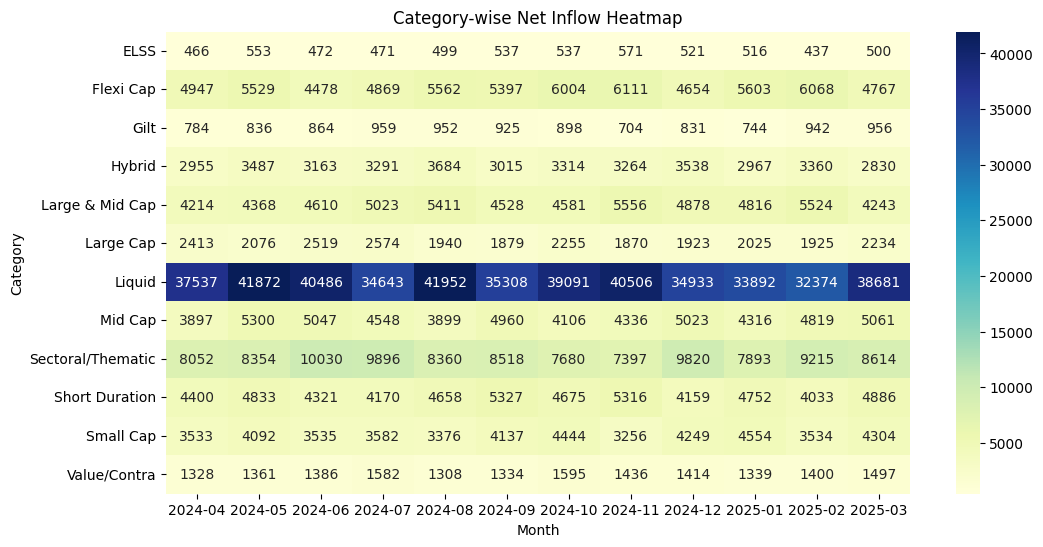

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

sns.heatmap(pivot_df,annot=True,fmt=".0f",cmap="YlGnBu"
)
plt.title("Category-wise Net Inflow Heatmap")
plt.xlabel("Month")
plt.ylabel("Category")

plt.show()

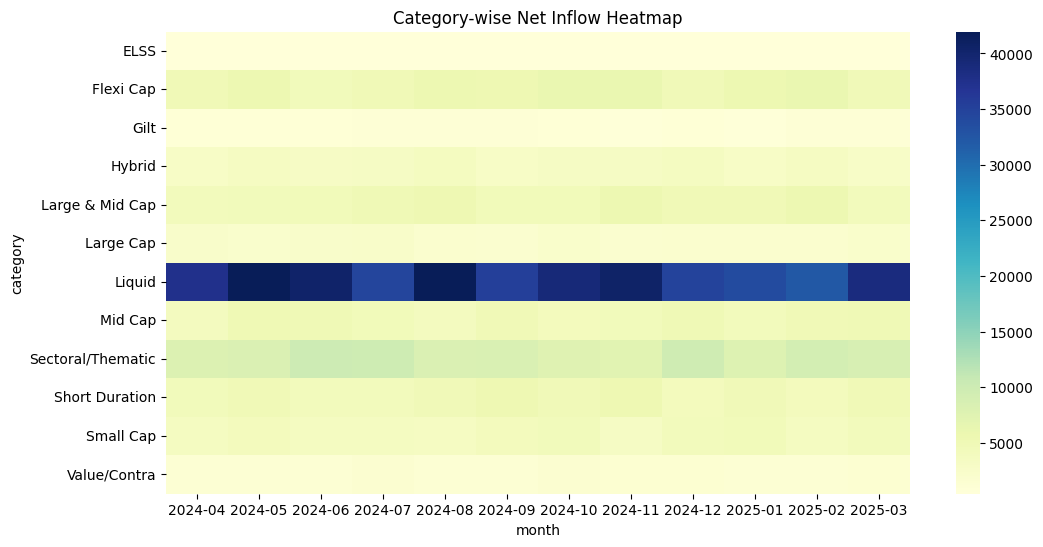

In [ ]:
plt.figure(figsize=(12,6))
sns.heatmap( pivot_df,cmap="YlGnBu"
)
plt.title("Category-wise Net Inflow Heatmap")
plt.savefig("../charts/category_heatmap.png",
            bbox_inches="tight")

plt.show()

### Insight 4

Flexi Cap, Mid Cap, and Small Cap categories consistently attracted higher net inflows, indicating strong investor preference for growth-oriented equity funds.

In [ ]:
folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")
print(folio.columns.tolist())
folio.head()

['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']


,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01,13.26,9.28,1.86,0.80,1.33
1,2022-04,13.91,9.74,1.95,0.83,1.39
2,2022-07,13.85,9.69,1.94,0.83,1.38
3,2022-10,14.12,9.88,1.98,0.85,1.41
4,2023-01,14.81,10.37,2.07,0.89,1.48


In [ ]:
folio['month'] = pd.to_datetime(folio['month'])
folio.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01-01,13.26,9.28,1.86,0.80,1.33
1,2022-04-01,13.91,9.74,1.95,0.83,1.39
2,2022-07-01,13.85,9.69,1.94,0.83,1.38
3,2022-10-01,14.12,9.88,1.98,0.85,1.41
4,2023-01-01,14.81,10.37,2.07,0.89,1.48


In [ ]:
import plotly.express as px

fig = px.line(folio,
    x='month', y='total_folios_crore',markers=True,title='Industry Folio Growth (2022-2025)'
)

fig.show()